In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_rows', 1000)



In [2]:
data25 = pd.read_csv('data2025.csv')
data24 = pd.read_csv('data2024.csv')
data23 = pd.read_csv('data2023.csv')
data22 = pd.read_csv('data2022.csv')

In [3]:
outs = [
    'field_out', 'force_out', 'grounded_into_double_play',
    'sac_fly', 'sac_bunt', 'fielders_choice', 'double_play',
    'fielders_choice_out',
    'sac_fly_double_play', 'triple_play', 'popup', 'strikeout', 'strikeout_double_play'
]

strikeout_code = ['strikeout', 'strikeout_double_play']

swing_code = ['foul_bunt', 'foul', 'hit_into_play', 'swinging_strike', 'foul_tip', 'swinging_strike_blocked', 'missed_bunt', 'bunt_foul_tip']
whiff_code = ['swinging_strike', 'foul_tip', 'swinging_strike_blocked']

out_code = ['field_out', 'grounded_into_double_play', 'force_out', 'sac_bunt',
            'double_play', 'fielders_choice_out', 'sac_fly']

bip_code = ['hit_into_play']

hit_code = ['single', 'double', 'triple', 'home_run']

walk_code = ['walk', 'intent_walk', 'hit_by_pitch']

strike_code = ['swinging_strike', 'swinging_strike_blocked', 'called_strike',  'missed_bunt']

foul_code = ['foul', 'foul_bunt', 'foul_tip', 'bunt_foul_tip']

ball_code = ['ball', 'blocked_ball']


In [ ]:
import sys
from pathlib import Path

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / 'src').exists():
    project_root = project_root.parent
if (project_root / 'src').exists():
    sys.path.insert(0, str(project_root))

from model_shared.db import get_read_cursor

def categorize_pitch(row):
    event = row['events']
    bb_type = row['bb_type']
    description = row['description']

    if event in strikeout_code:
        return 'strikeout'
    elif event in out_code:
        if bb_type == 'ground_ball':
            return 'groundout'
        elif bb_type in ['fly_ball', 'line_drive', 'popup']:
            return 'flyout'
    elif event in hit_code:
        return 'hit'
    elif event in walk_code:
        return 'walk'
    
    if description in strike_code:
        return 'strike'
    elif description in foul_code:
        return 'foul'
    elif description in ball_code:
        return 'ball'
    
    return 'other'
        

def get_historical_data(year=2024):
    query = """
        SELECT
            bb.player_id,
            bb.position,
            bb.ground_ball_percentage,
            bb.air_ball_percentage,
            pd.whiff_percentage,
            pd.chase_percentage,
            pd.zone_percentage,
            pd.zone_swing_percentage,
            pd.zone_contact_percentage,
            qoc.weak_percentage,
            qoc.under_percentage,
            qoc.topped_percentage,
            qoc.flareburner_percentage,
            qoc.solid_percentage,
            qoc.barrel_percentage,
            qoc.barrels_per_pa,
            pt.pitch_type,
            pt.pitch_count,
            pt.strikeouts,
            pt.batted_ball_events,
            pt.batting_average,
            pt.putaway_percentage,
            pt.whiff_percentage AS pitch_whiff_percentage,
            pt.launch_angle AS avg_la,
            pt.exit_velocity AS avg_ev,
            pt.expected_batting_average
        FROM batted_ball_profile bb 
        JOIN plate_discipline pd
            ON bb.player_id = pd.player_id
            AND bb.position = pd.position
            AND bb.year = pd.year
        JOIN quality_of_contact qoc
            ON bb.player_id = qoc.player_id
            AND bb.position = qoc.position
            AND bb.year = qoc.year
        JOIN pitch_tracking pt
            ON bb.player_id = pt.player_id
            AND bb.position = pt.position
            AND bb.year = pt.year
        WHERE bb.year = %s;
    """

    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))
    return df

def df_process(df):
    df = df.sort_values(['game_date', 'game_pk', 'at_bat_number', 'pitch_number'])

    df['outcome'] = df.apply(categorize_pitch, axis=1)

    df['prev_pitch_type'] = df.groupby(['game_pk', 'at_bat_number'])['pitch_type'].shift(1)
    df['prev_pitch_type'] = df['prev_pitch_type'].fillna('NONE')

    df['runner_on_1b'] = df['on_1b'].notna().astype(int)
    df['runner_on_2b'] = df['on_2b'].notna().astype(int)
    df['runner_on_3b'] = df['on_3b'].notna().astype(int)

    return df

In [5]:
def get_features(out_data, features):
    final_features = list(features)
    if 'prev_pitch_type' in out_data.columns and 'prev_pitch_type' not in final_features:
        final_features.append('prev_pitch_type')

    model_data = out_data[final_features]

    cat_cols = ['pitch_type', 'stand', 'p_throws', 'inning_topbot']
    if 'prev_pitch_type' in model_data.columns:
        cat_cols.append('prev_pitch_type')

    existing_cat_cols = [c for c in cat_cols if c in model_data.columns]
    model_data = pd.get_dummies(model_data, columns=existing_cat_cols, drop_first=True)
    return model_data

In [6]:
def get_zone_metrics(year=2024):
    query = """
        SELECT
            player_id,
            position,
            metric,
            zone1,
            zone2,
            zone3,
            zone4,
            zone5,
            zone6,
            zone7,
            zone8,
            zone9,
            zone11,
            zone12,
            zone13,
            zone14
        FROM zone_metrics
        WHERE year = %s
            AND metric IN ('batting_average', 'average_exit_velocity', 
                          'average_launch_angle', 'contact_batting_average',
                          'hard_hit_bip_percentage', 'expected_batting_average',
                          'strikeout_percentage', 'whiff_percentage', 'walk_percentage', 'ground_ball_percentage',
                          'line_drive_percentage', 'fly_ball_percentage', 'popup_percentage', 'swing_percentage'
                          )
    """
    with get_read_cursor() as cursor:
        df = pd.read_sql(query, cursor.connection, params=(year,))

    df_long = pd.melt(
        df, 
        id_vars=['player_id', 'position', 'metric'], 
        var_name='zone', 
        value_name='metric_value'
    )
    df_long['zone'] = df_long['zone'].str.replace('zone', '').astype(int)
    
    df_final = df_long.pivot_table(
        index=['player_id', 'position', 'zone'], 
        columns='metric', 
        values='metric_value'
    ).reset_index()
    
    return df_final


features = [
    'p_throws', 
    'stand', 
    'balls', 
    'pitch_type',
    'zone',
    'strikes', 
    'runner_on_1b',
    'runner_on_2b', 
    'runner_on_3b', 
    'outs_when_up', 
    'inning',
    'bat_score',
    'fld_score',
    'inning_topbot',
    'sz_top',
    'sz_bot',
    # 'batter_rolling_whiff_rate', 
    # 'batter_rolling_gb_rate', 
    # 'batter_rolling_fb_rate', 
    'batter_prev_whiff_rate', 
    'batter_prev_gb_rate', 
    'batter_prev_fb_rate',
    'batter_prev_chase_rate',
    'batter_prev_weak_rate',
    'batter_prev_under_rate',
    'batter_prev_topped_rate',
    'batter_prev_flareburner_rate',
    'batter_prev_solid_rate',
    'batter_prev_barrel_rate',
    'batter_prev_barrels_per_pa',
    'batter_prev_looking_strike_rate',
    'batter_prev_zone_contact_rate',
    'pitcher_prev_fb_rate', 
    'pitcher_prev_gb_rate', 
    'pitcher_prev_whiff_rate', 
    'game_year',
    'game_date', 'game_pk', 'pitch_number',
    # 'pitcher_rolling_whiff_rate', 
    # 'pitcher_rolling_gb_rate', 
    # 'pitcher_rolling_fb_rate', 
    'pitcher_prev_chase_rate',
    'pitcher_prev_weak_rate',
    'pitcher_prev_under_rate',
    'pitcher_prev_topped_rate',
    'pitcher_prev_flareburner_rate',
    'pitcher_prev_solid_rate',
    'pitcher_prev_barrel_rate',
    'pitcher_prev_barrels_per_pa',
    'outcome',
    'pitcher_pitch_putaway_rate',
    'batter_pitch_putaway_rate',
    'pitcher_pitch_whiff_rate',
    'batter_pitch_whiff_rate',
    'pitcher_pitch_avg_la',
    'pitcher_pitch_avg_ev',
    'pitcher_pitch_expected_batting_average',
    'batter_pitch_avg_la',
    'batter_pitch_avg_ev',
    'batter_pitch_expected_batting_average',
    'pitcher_pitch_batting_average',
    'batter_pitch_batting_average',
    'pitcher_zone_batting_average',
    'batter_zone_batting_average',
    'pitcher_zone_average_exit_velocity',
    'batter_zone_average_exit_velocity',
    'pitcher_zone_average_launch_angle',
    'batter_zone_average_launch_angle',
    'pitcher_zone_contact_batting_average',
    'batter_zone_contact_batting_average',
    'pitcher_zone_hard_hit_bip_percentage',
    'batter_zone_hard_hit_bip_percentage',
    'pitcher_zone_expected_batting_average',
    'batter_zone_expected_batting_average',
    'batter_zone_strikeout_percentage',
    'pitcher_zone_strikeout_percentage',
    'batter_zone_whiff_percentage',
    'pitcher_zone_whiff_percentage',
    'batter_zone_fly_ball_rate',
    'pitcher_zone_fly_ball_rate',
    'batter_zone_walk_percentage',
    'pitcher_zone_walk_percentage',
    'batter_zone_ground_ball_percentage',
    'pitcher_zone_ground_ball_percentage',
    'batter_zone_swing_percentage',
    'pitcher_zone_swing_percentage',
]


def build_season_features(current_pitch_data, historical_year):
    historical_df = get_historical_data(historical_year)
    zone_metrics_df = get_zone_metrics(historical_year)

    prev_cols = [
        'player_id', 'position', 'ground_ball_percentage', 'air_ball_percentage',
        'whiff_percentage', 'chase_percentage', 'weak_percentage', 
        'under_percentage', 'topped_percentage', 'zone_contact_percentage',
        'zone_percentage', 'zone_swing_percentage', 'flareburner_percentage', 'solid_percentage', 'barrel_percentage', 'barrels_per_pa'
    ]

    batter_baselines = historical_df[historical_df['position'] == 'B'][prev_cols].drop_duplicates().add_prefix('batter_prev_')
    pitcher_baselines = historical_df[historical_df['position'] == 'P'][prev_cols].drop_duplicates().add_prefix('pitcher_prev_')

    pitch_data = current_pitch_data.merge(batter_baselines, left_on='batter', right_on='batter_prev_player_id', how='left')
    pitch_data = pitch_data.merge(pitcher_baselines, left_on='pitcher', right_on='pitcher_prev_player_id', how='left')

    pt_cols = [
        'player_id', 'position', 'pitch_type', 'pitch_count', 'strikeouts', 'batted_ball_events',
        'batting_average', 'putaway_percentage', 'pitch_whiff_percentage', 'avg_la', 'avg_ev', 'expected_batting_average'
    ]

    batter_pt = historical_df[historical_df['position'] == 'B'][pt_cols].drop_duplicates().add_prefix('batter_pitch_')
    pitcher_pt = historical_df[historical_df['position'] == 'P'][pt_cols].drop_duplicates().add_prefix('pitcher_pitch_')

    pitch_data = pitch_data.merge(batter_pt, left_on=['batter', 'pitch_type'], right_on=['batter_pitch_player_id', 'batter_pitch_pitch_type'], how='left')
    pitch_data = pitch_data.merge(pitcher_pt, left_on=['pitcher', 'pitch_type'], right_on=['pitcher_pitch_player_id', 'pitcher_pitch_pitch_type'], how='left')

    batter_zone = zone_metrics_df[zone_metrics_df['position'] == 'B'].add_prefix('batter_zone_')
    pitcher_zone = zone_metrics_df[zone_metrics_df['position'] == 'P'].add_prefix('pitcher_zone_')

    pitch_data = pitch_data.merge(batter_zone, left_on=['batter', 'zone'], right_on=['batter_zone_player_id', 'batter_zone_zone'], how='left')
    pitch_data = pitch_data.merge(pitcher_zone, left_on=['pitcher', 'zone'], right_on=['pitcher_zone_player_id', 'pitcher_zone_zone'], how='left')

    pitch_data = pitch_data.rename(columns={
        'batter_prev_ground_ball_percentage': 'batter_prev_gb_rate', 
        'batter_prev_air_ball_percentage': 'batter_prev_fb_rate',
        'batter_prev_whiff_percentage': 'batter_prev_whiff_rate',
        'batter_prev_chase_percentage': 'batter_prev_chase_rate',
        'batter_prev_weak_percentage': 'batter_prev_weak_rate',
        'batter_prev_under_percentage': 'batter_prev_under_rate',
        'batter_prev_topped_percentage': 'batter_prev_topped_rate',
        'batter_prev_flareburner_percentage': 'batter_prev_flareburner_rate',
        'batter_prev_solid_percentage': 'batter_prev_solid_rate',
        'batter_prev_barrel_percentage': 'batter_prev_barrel_rate',
        'batter_prev_barrels_per_pa': 'batter_prev_barrels_per_pa',
        'batter_prev_zone_contact_percentage': 'batter_prev_zone_contact_rate',
        'batter_pitch_putaway_percentage': 'batter_pitch_putaway_rate',
        'batter_pitch_pitch_whiff_percentage': 'batter_pitch_whiff_rate',
        'pitcher_prev_ground_ball_percentage': 'pitcher_prev_gb_rate', 
        'pitcher_prev_air_ball_percentage': 'pitcher_prev_fb_rate',
        'pitcher_prev_whiff_percentage': 'pitcher_prev_whiff_rate',
        'pitcher_prev_chase_percentage': 'pitcher_prev_chase_rate',
        'pitcher_prev_weak_percentage': 'pitcher_prev_weak_rate',
        'pitcher_prev_under_percentage': 'pitcher_prev_under_rate',
        'pitcher_prev_topped_percentage': 'pitcher_prev_topped_rate',
        'pitcher_prev_flareburner_percentage': 'pitcher_prev_flareburner_rate',
        'pitcher_prev_solid_percentage': 'pitcher_prev_solid_rate',
        'pitcher_prev_barrel_percentage': 'pitcher_prev_barrel_rate',
        'pitcher_prev_barrels_per_pa': 'pitcher_prev_barrels_per_pa',
        'pitcher_pitch_putaway_percentage': 'pitcher_pitch_putaway_rate',
        'pitcher_pitch_pitch_whiff_percentage': 'pitcher_pitch_whiff_rate',
    })

    pitch_data['batter_prev_looking_strike_rate'] = pitch_data['batter_prev_zone_percentage'] * (1 - pitch_data['batter_prev_zone_swing_percentage'] / 100.0)
    pitch_data['batter_zone_fly_ball_rate'] = pitch_data['batter_zone_line_drive_percentage'] + pitch_data['batter_zone_fly_ball_percentage'] + pitch_data['batter_zone_popup_percentage']
    pitch_data['pitcher_zone_fly_ball_rate'] = pitch_data['pitcher_zone_line_drive_percentage'] + pitch_data['pitcher_zone_fly_ball_percentage'] + pitch_data['pitcher_zone_popup_percentage']

    pitch_data = pitch_data.drop(columns=[
        'batter_prev_zone_swing_percentage',
        'batter_prev_zone_percentage', 
        'pitcher_prev_zone_swing_percentage',
        'pitcher_prev_zone_percentage',
        'pitcher_prev_zone_contact_percentage',
    ])

    sql_pct_cols = [
        'batter_prev_fb_rate', 'batter_prev_gb_rate', 'batter_prev_whiff_rate',
        'batter_prev_chase_rate', 'batter_prev_weak_rate', 'batter_prev_under_rate',
        'batter_prev_topped_rate', 'batter_prev_flareburner_rate', 'batter_prev_solid_rate', 'batter_prev_barrel_rate', 
        'batter_prev_barrels_per_pa', 'batter_prev_looking_strike_rate',
        'batter_prev_zone_contact_rate', 'batter_pitch_putaway_rate',
        'batter_pitch_whiff_rate', 'pitcher_prev_fb_rate', 'pitcher_prev_gb_rate',
        'pitcher_prev_whiff_rate', 'pitcher_prev_chase_rate', 'pitcher_prev_weak_rate',
        'pitcher_prev_under_rate', 'pitcher_prev_topped_rate', 'pitcher_prev_flareburner_rate', 'pitcher_prev_solid_rate', 'pitcher_prev_barrel_rate', 
        'pitcher_prev_barrels_per_pa', 'pitcher_pitch_putaway_rate', 'pitcher_pitch_whiff_rate'
    ]

    for col in sql_pct_cols:
        if col in pitch_data.columns:
            pitch_data[col] = pitch_data[col] / 100.0
            
    return pitch_data


df_25 = df_process(data25)
df_24 = df_process(data24)
df_23 = df_process(data23)
df_22 = df_process(data22)

pitch_data_25 = build_season_features(df_25, historical_year=2024)
pitch_data_24 = build_season_features(df_24, historical_year=2023)
pitch_data_23 = build_season_features(df_23, historical_year=2022)
pitch_data_22 = build_season_features(df_22, historical_year=2021)

pitch_data = pd.concat([pitch_data_22, pitch_data_23, pitch_data_24, pitch_data_25], ignore_index=True)

print("Total combined rows:", len(pitch_data))

model_data = get_features(pitch_data, features)

C:\Users\Lucas\AppData\Local\Temp\ipykernel_28616\2449728730.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_28616\3534305659.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\Lucas\AppData\Local\Temp\ipykernel_28616\2449728730.py:85: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cursor.connection, params=(year,))
C:\Users\L

Total combined rows: 2896534


[0]	validation_0-aucpr:0.49523
[100]	validation_0-aucpr:0.51723
[200]	validation_0-aucpr:0.51907
[300]	validation_0-aucpr:0.51963
[400]	validation_0-aucpr:0.52014
[468]	validation_0-aucpr:0.52014
two_strikes                               0.230096
zone                                      0.170234
strikes                                   0.133418
prev_pitch_type_NONE                      0.051883
batter_zone_swing_percentage              0.037068
pitch_type_FF                             0.019222
balls                                     0.016402
pitcher_zone_swing_percentage             0.015637
pitch_type_SI                             0.011448
batter_zone_strikeout_percentage          0.008646
sz_bot                                    0.008582
batter_zone_walk_percentage               0.008490
pitch_type_CU                             0.008369
sz_top                                    0.007860
prev_pitch_type_EP                        0.007818
pitch_type_FA                          

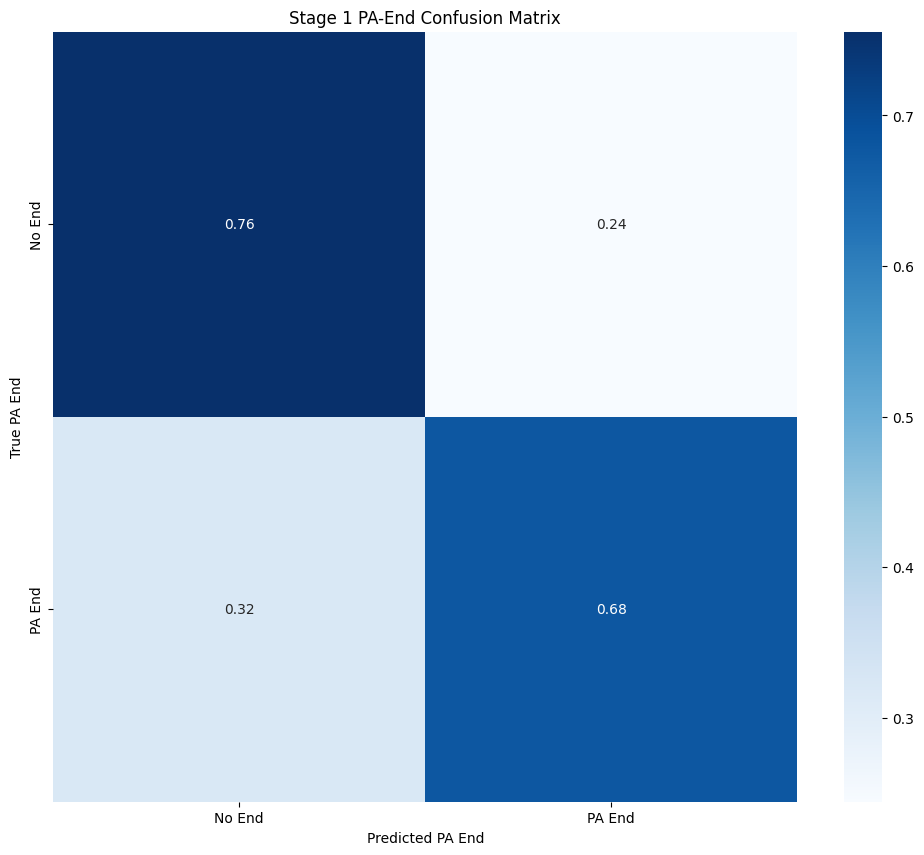

[0]	validation_0-aucpr:0.65632
[100]	validation_0-aucpr:0.69034
[200]	validation_0-aucpr:0.70062
[300]	validation_0-aucpr:0.70332
[400]	validation_0-aucpr:0.70356
[423]	validation_0-aucpr:0.70330
strikes                                   0.590103
two_strikes                               0.331012
prev_pitch_type_NONE                      0.008350
batter_zone_whiff_percentage              0.005173
zone                                      0.004612
batter_zone_strikeout_percentage          0.002751
pitch_type_FF                             0.002144
batter_zone_swing_percentage              0.001891
pitcher_zone_whiff_percentage             0.001399
pitcher_zone_strikeout_percentage         0.001392
prev_pitch_type_FA                        0.001296
batter_prev_whiff_rate                    0.001104
prev_pitch_type_FF                        0.001048
p_throws_R                                0.000924
pitch_type_SI                             0.000898
pitcher_zone_swing_percentage          

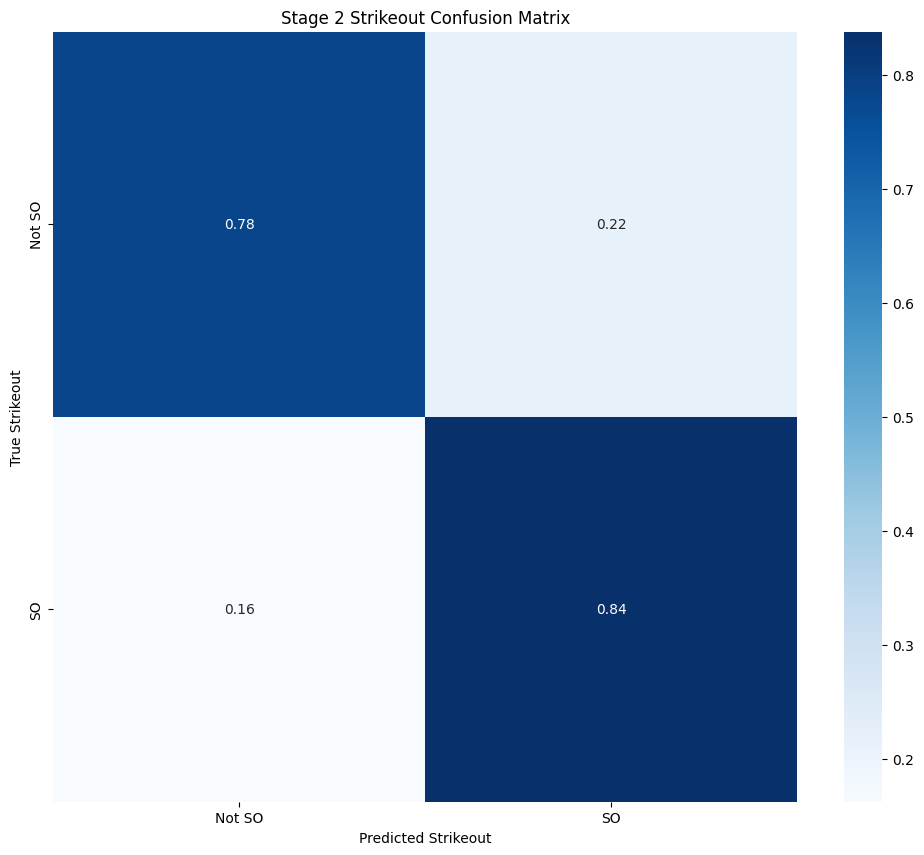

pitch_type_FF                             0.071262
zone                                      0.070962
pitch_type_SI                             0.063354
pitcher_pitch_avg_la                      0.035861
pitch_type_ST                             0.024415
batter_zone_average_launch_angle          0.021064
is_platoon                                0.017471
batter_pitch_avg_la                       0.017169
pitch_type_SL                             0.012932
pitch_type_FS                             0.010647
batter_zone_average_exit_velocity         0.010318
strikes                                   0.010140
prev_pitch_type_FA                        0.009680
batter_zone_fly_ball_rate                 0.009552
batter_zone_hard_hit_bip_percentage       0.009387
pitch_type_FA                             0.009322
stand_R                                   0.009189
batter_prev_fb_rate                       0.008786
pitcher_prev_gb_rate                      0.008649
two_strikes                    

c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:3091: UserWarning: labels size, 4, does not match size of target_names, 3
  warnings.warn(
c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lucas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classificat

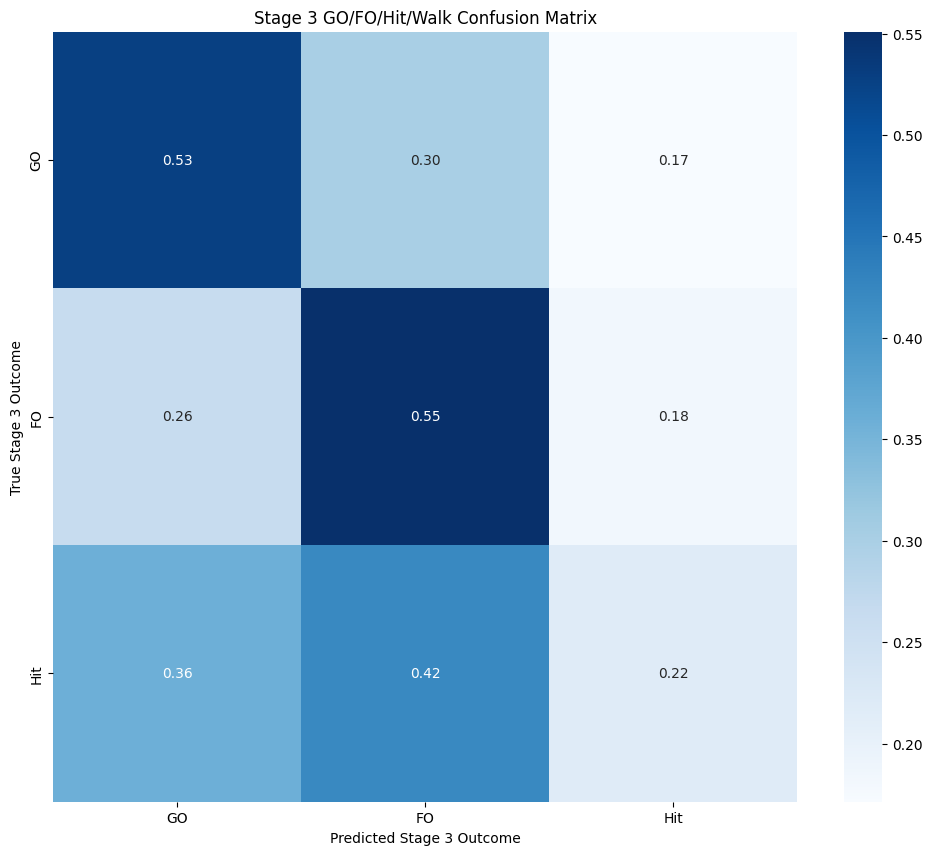

          P(None)  P(SO)     P(GO)     P(FO)  prob_sum
2462179  0.872343    0.0  0.057726  0.069931       1.0
2462180  1.000000    0.0  0.000000  0.000000       1.0
2462191  0.828678    0.0  0.044600  0.126722       1.0
2462194  0.992269    0.0  0.004906  0.002824       1.0
2462199  0.995176    0.0  0.002638  0.002187       1.0
Probability sum min/max: 1.000000 / 1.000000
Overall Multi-Class Log Loss (None/SO/GO/FO): 0.5183


In [11]:
from matplotlib import pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
from sklearn.utils import compute_sample_weight
import xgboost as xgb
import pandas as pd
import seaborn as sns
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import log_loss

bb_out_labels = {
    'groundout': 0,
    'flyout': 1,
    'hit': 2,
    'walk': 3
}

model_data['target1'] = model_data['outcome'].isin(['strikeout', 'groundout', 'flyout', 'hit']).astype(int)
model_data['target2'] = (model_data['outcome'] == 'strikeout').astype(int)
model_data['target3'] = model_data['outcome'].map(bb_out_labels)

model_data['two_strikes'] = (model_data['strikes'] == 2).astype(int)
model_data['full_count'] = ((model_data['balls'] == 3) & (model_data['strikes'] == 2)).astype(int)
model_data['is_platoon'] = model_data['p_throws_R'] != model_data['stand_R']

features = [col for col in model_data.columns if col not in ['target1', 'target2', 'target3', 'outcome', 'game_date', 'game_pk', 'pitch_number']]
model_data = model_data.sort_values(['game_date', 'game_pk', 'pitch_number'])

n_total = len(model_data)
train_end = int(n_total * 0.70)
cal_end = int(n_total * 0.85)

train_data = model_data.iloc[:train_end]
cal_data = model_data.iloc[train_end:cal_end]
test_data = model_data.iloc[cal_end:]

X1_train = train_data[features]
y1_train = train_data['target1']

X1_cal = cal_data[features]
y1_cal = cal_data['target1']

X1_test = test_data[features]
y1_test = test_data['target1']

xgb_out = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42
)

xgb_out.fit(X1_train, y1_train, eval_set=[(X1_cal, y1_cal)], verbose=100)

calibrated_out = CalibratedClassifierCV(FrozenEstimator(xgb_out), method='isotonic')
calibrated_out.fit(X1_cal, y1_cal)

y1_proba = calibrated_out.predict_proba(X1_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y1_test, y1_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
pa_threshold = thresholds[optimal_idx]
y1_pred_optimized = (y1_proba >= pa_threshold).astype(int)

importance = pd.Series(
    xgb_out.feature_importances_,
    index=X1_train.columns
).sort_values(ascending=False)
print(importance)

print(f"Optimal threshold: {pa_threshold:.3f}")
print(classification_report(y1_test, y1_pred_optimized, target_names=['No End', 'PA End']))

cm = confusion_matrix(y1_test, y1_pred_optimized)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt=".2f",
    annot=True,
    xticklabels=['No End', 'PA End'],
    yticklabels=['No End', 'PA End']
)
plt.xlabel("Predicted PA End")
plt.ylabel("True PA End")
plt.title("Stage 1 PA-End Confusion Matrix")
plt.show()

train_data_s2 = train_data[train_data['target1'] == 1]
cal_data_s2 = cal_data[cal_data['target1'] == 1]
test_data_s2 = test_data[test_data['target1'] == 1]

X2_train = train_data_s2[features]
y2_train = train_data_s2['target2']

X2_cal = cal_data_s2[features]
y2_cal = cal_data_s2['target2']

X2_test = test_data_s2[features]
y2_test = test_data_s2['target2']

xgb_so = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=1500,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=10,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='aucpr',
    early_stopping_rounds=50,
    random_state=42
)

xgb_so.fit(X2_train, y2_train, eval_set=[(X2_cal, y2_cal)], verbose=100)

calibrated_so = CalibratedClassifierCV(FrozenEstimator(xgb_so), method='isotonic')
calibrated_so.fit(X2_cal, y2_cal)

y2_proba = calibrated_so.predict_proba(X2_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y2_test, y2_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
so_threshold = thresholds[optimal_idx]
y2_pred_optimized = (y2_proba >= so_threshold).astype(int)

importance = pd.Series(
    xgb_so.feature_importances_,
    index=X2_train.columns
).sort_values(ascending=False)
print(importance)

print(f"Optimal threshold: {so_threshold:.3f}")
print(classification_report(y2_test, y2_pred_optimized, target_names=['Not SO', 'SO']))

cm = confusion_matrix(y2_test, y2_pred_optimized)
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt=".2f",
    annot=True,
    xticklabels=['Not SO', 'SO'],
    yticklabels=['Not SO', 'SO']
)
plt.xlabel("Predicted Strikeout")
plt.ylabel("True Strikeout")
plt.title("Stage 2 Strikeout Confusion Matrix")
plt.show()

stage3_drop_cols = [
    'target1', 'target2', 'target3', 'outcome', 'game_date', 'game_pk', 'pitch_number',
    'batter_prev_whiff_rate', 'pitcher_prev_whiff_rate',
    'batter_prev_looking_strike_rate', 'batter_prev_zone_contact_rate',
    'batter_prev_chase_rate', 'pitcher_prev_chase_rate'
]

train_data_s3 = train_data[(train_data['target1'] == 1) & (train_data['target2'] == 0)]
cal_data_s3 = cal_data[(cal_data['target1'] == 1) & (cal_data['target2'] == 0)]
test_data_s3 = test_data[(test_data['target1'] == 1) & (test_data['target2'] == 0)]

X3_train = train_data_s3[features]
y3_train = train_data_s3['target3']

X3_cal = cal_data_s3[features]
y3_cal = cal_data_s3['target3']

X3_test = test_data_s3[features]
y3_test = test_data_s3['target3']

X3_combined = pd.concat([X3_train, X3_cal], axis=0)
y3_combined = pd.concat([y3_train, y3_cal], axis=0)
                        
weights = compute_sample_weight(class_weight='balanced', y=y3_combined)

xgb_bb = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    tree_method='hist',
    n_jobs=-1,
    max_depth=6,
    n_estimators=300,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
)

xgb_bb.fit(X3_combined, y3_combined, sample_weight=weights, verbose=100)

calibrated_bb = CalibratedClassifierCV(xgb_bb, method='sigmoid', cv=5)
calibrated_bb.fit(X3_combined, y3_combined, sample_weight=weights)

y3_proba = calibrated_bb.predict_proba(X3_test)
y3_pred_optimized = np.argmax(y3_proba, axis=1)

importance = pd.Series(
    xgb_bb.feature_importances_,
    index=X3_train.columns
).sort_values(ascending=False)

print(importance)

print(classification_report(
    y3_test,
    y3_pred_optimized,
    labels=[0, 1, 2, 3],
    target_names=['GO', 'FO', 'Hit']
))

cm = confusion_matrix(y3_test, y3_pred_optimized, labels=[0, 1, 2])
print(cm)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    cmap="Blues",
    fmt=".2f",
    annot=True,
    xticklabels=['GO', 'FO', 'Hit'],
    yticklabels=['GO', 'FO', 'Hit']
)
plt.xlabel("Predicted Stage 3 Outcome")
plt.ylabel("True Stage 3 Outcome")
plt.title("Stage 3 GO/FO/Hit/Walk Confusion Matrix")
plt.show()

def get_pitch_probabilities(X_full, xgb_pa, xgb_so, xgb_bb, X3_columns):
    p_pa_end = xgb_pa.predict_proba(X_full)[:, 1]
    p_no_end = 1.0 - p_pa_end

    p_so_given_end = xgb_so.predict_proba(X_full)[:, 1]

    X_for_stage3 = X_full.reindex(columns=X3_columns, fill_value=0.0)
    stage3_probs = xgb_bb.predict_proba(X_for_stage3)
    p_go_given_non_so_end = stage3_probs[:, 0]
    p_fo_given_non_so_end = stage3_probs[:, 1]
    p_hit_given_non_so_end = stage3_probs[:, 2]

    p_so = p_pa_end * p_so_given_end
    p_non_so_end = p_pa_end * (1.0 - p_so_given_end)

    p_go = p_non_so_end * p_go_given_non_so_end
    p_fo = p_non_so_end * p_fo_given_non_so_end
    p_hit = p_non_so_end * p_hit_given_non_so_end

    p_none = p_no_end + p_hit

    out = pd.DataFrame({
        'P(None)': p_none,
        'P(SO)': p_so,
        'P(GO)': p_go,
        'P(FO)': p_fo
    }, index=X_full.index)

    out['prob_sum'] = out[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)']].sum(axis=1)
    return out

prob_df = get_pitch_probabilities(X1_test, calibrated_out, calibrated_so, calibrated_bb, X3_train.columns)
print(prob_df.head())
print(f"Probability sum min/max: {prob_df['prob_sum'].min():.6f} / {prob_df['prob_sum'].max():.6f}")

y_true = model_data.loc[X1_test.index, 'outcome'].map({
    'other': 0, 'ball': 0, 'foul': 0, 'strike': 0, 'hit': 0, 'walk': 0,
    'strikeout': 1,
    'groundout': 2,
    'flyout': 3
}).fillna(0).astype(int)

final_prob_cols = ['P(None)', 'P(SO)', 'P(GO)', 'P(FO)']
multi_log_loss = log_loss(y_true, prob_df[final_prob_cols], labels=[0, 1, 2, 3])
print(f"Overall Multi-Class Log Loss (None/SO/GO/FO): {multi_log_loss:.4f}")

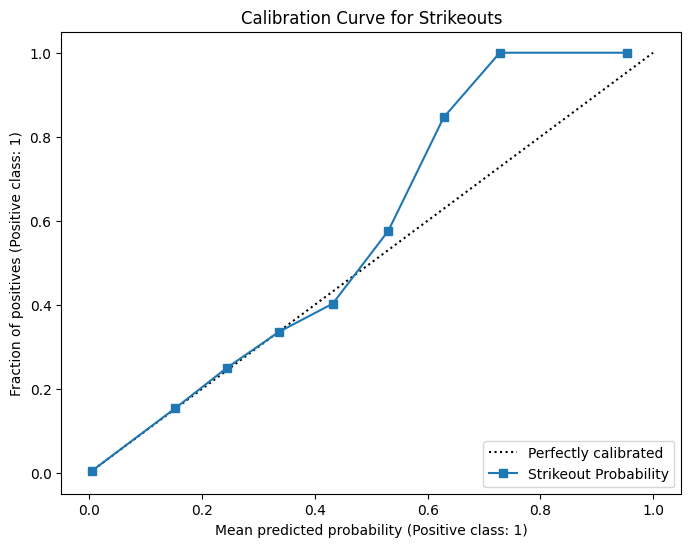

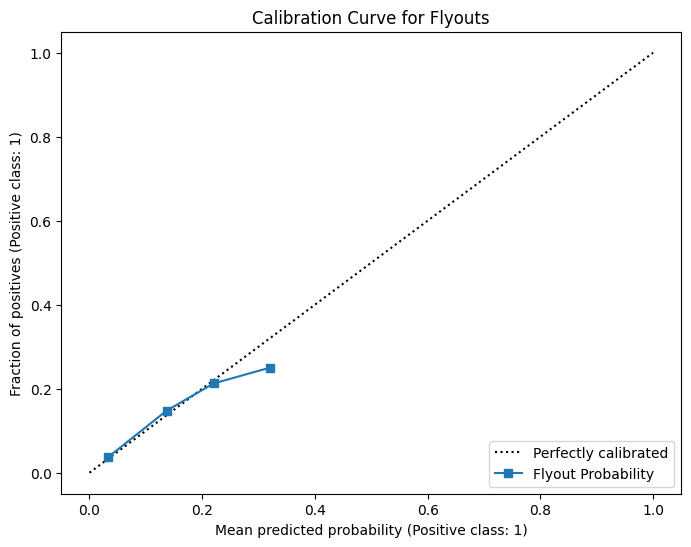

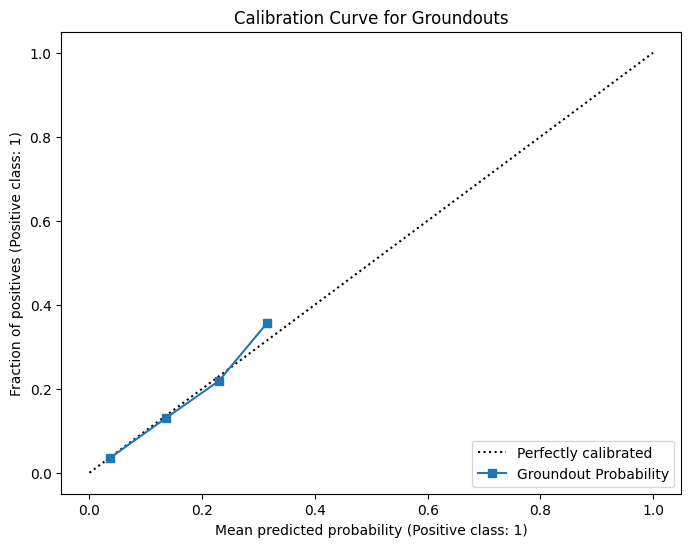

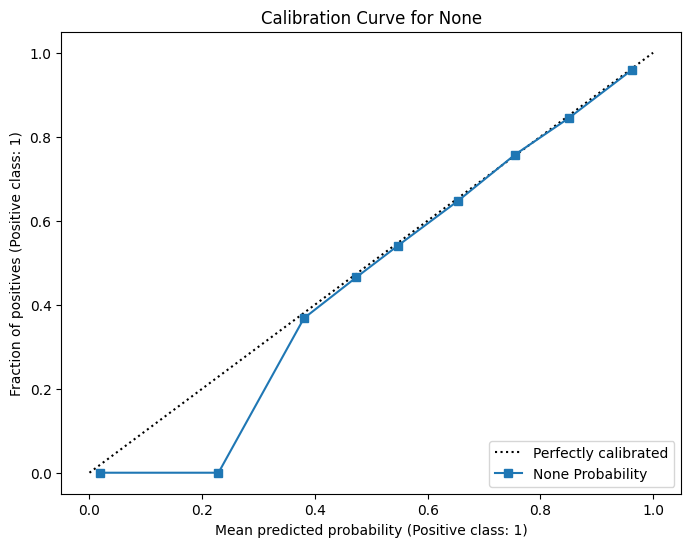

Raw SO Log Loss: 0.3266
Calibrated SO Log Loss: 0.3275
Raw Stage3 Log Loss (BB): 1.0576
Calibrated Stage3 Log Loss (BB): 1.0568
Raw PA End Log Loss: 0.4324
Calibrated PA End Log Loss: 0.4322
Highest P(SO): 95.41%
          P(None)     P(SO)     P(GO)     P(FO)     actual
2728401  0.018828  0.954128  0.014636  0.012408  strikeout
2670819  0.228917  0.728028  0.016486  0.026570  strikeout
2597266  0.330983  0.669017  0.000000  0.000000  strikeout
2849540  0.330983  0.669017  0.000000  0.000000       ball
2624252  0.351503  0.648497  0.000000  0.000000  strikeout
2654876  0.337934  0.641598  0.008451  0.012018  strikeout
2696219  0.364712  0.635288  0.000000  0.000000  strikeout
2714099  0.350791  0.630437  0.008409  0.010364  strikeout
2766357  0.343456  0.627614  0.016512  0.012418  strikeout
2587028  0.345956  0.624416  0.016452  0.013176  strikeout
2768030  0.366365  0.612900  0.006407  0.014328  strikeout
2696495  0.373907  0.606146  0.009297  0.010649  strikeout
2730112  0.353494  0

In [12]:
from sklearn.calibration import CalibrationDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 1).astype(int),
    prob_df['P(SO)'],
    n_bins=10,
    ax=ax,
    name='Strikeout Probability'
)
plt.title('Calibration Curve for Strikeouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 3).astype(int),
    prob_df['P(FO)'],
    n_bins=10,
    ax=ax,
    name='Flyout Probability'
)
plt.title('Calibration Curve for Flyouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 2).astype(int),
    prob_df['P(GO)'],
    n_bins=10,
    ax=ax,
    name='Groundout Probability'
)
plt.title('Calibration Curve for Groundouts')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
CalibrationDisplay.from_predictions(
    (y_true == 0).astype(int),
    prob_df['P(None)'],
    n_bins=10,
    ax=ax,
    name='None Probability'
)
plt.title('Calibration Curve for None')
plt.show()

raw_loss_so = log_loss(y2_test, xgb_so.predict_proba(X2_test)[:, 1])
cal_loss_so = log_loss(y2_test, calibrated_so.predict_proba(X2_test)[:, 1])
print(f'Raw SO Log Loss: {raw_loss_so:.4f}')
print(f'Calibrated SO Log Loss: {cal_loss_so:.4f}')

raw_loss_stage3 = log_loss(y3_test, xgb_bb.predict_proba(X3_test), labels=[0, 1, 2])
cal_loss_stage3 = log_loss(y3_test, calibrated_bb.predict_proba(X3_test), labels=[0, 1, 2])
print(f'Raw Stage3 Log Loss (BB): {raw_loss_stage3:.4f}')
print(f'Calibrated Stage3 Log Loss (BB): {cal_loss_stage3:.4f}')

raw_loss_stage1 = log_loss(y1_test, xgb_out.predict_proba(X1_test)[:, 1])
cal_loss_stage1 = log_loss(y1_test, calibrated_out.predict_proba(X1_test)[:, 1])
print(f'Raw PA End Log Loss: {raw_loss_stage1:.4f}')
print(f'Calibrated PA End Log Loss: {cal_loss_stage1:.4f}')

results = X1_test.copy()
results[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)']] = prob_df[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)']]
results['actual'] = model_data.loc[X1_test.index, 'outcome']

top_so = results.sort_values('P(SO)', ascending=False).head(50)
print(f"Highest P(SO): {top_so['P(SO)'].iloc[0]:.2%}")
print(top_so[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual']])

top_fo = results.sort_values('P(FO)', ascending=False).head(50)
print(f"Highest P(FO): {top_fo['P(FO)'].iloc[0]:.2%}")
print(top_fo[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual']])

top_go = results.sort_values('P(GO)', ascending=False).head(50)
print(f"Highest P(GO): {top_go['P(GO)'].iloc[0]:.2%}")
print(top_go[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual']])

top_none = results.sort_values('P(None)', ascending=False).head(50)
print(f"Highest P(None): {top_none['P(None)'].iloc[0]:.2%}")
print(top_none[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual']])

lowest_none = results.sort_values('P(None)', ascending=True).head(50)
print(f"Lowest P(None): {lowest_none['P(None)'].iloc[0]:.2%}")
print(lowest_none[['P(None)', 'P(SO)', 'P(GO)', 'P(FO)', 'actual']])

raw_stage3_probs = xgb_bb.predict_proba(X3_test)
cal_stage3_probs = calibrated_bb.predict_proba(X3_test)
comparison_df = pd.DataFrame({
    'Raw_FO_Prob': raw_stage3_probs[:, 1],
    'Calibrated_FO_Prob': cal_stage3_probs[:, 1],
    'Actual_FO': (y3_test == 1).astype(int)
})

outliers = comparison_df[
    (comparison_df['Raw_FO_Prob'] >= 0.38) &
    (comparison_df['Raw_FO_Prob'] <= 0.42)
]
print(f"Average Calibrated FO Prob for 40% raw bin: {outliers['Calibrated_FO_Prob'].mean():.2%}")
print(f"Actual FO Rate in this bin: {outliers['Actual_FO'].mean():.2%}")
bad_bin_pitches = cal_stage3_probs[:, 1]
bad_bin_pitches = bad_bin_pitches[bad_bin_pitches >= 0.40]
print(f"Number of pitches in the 40%+ FO bin: {len(bad_bin_pitches)}")